# 03 - Análisis exploratorio de datos (EDA)

**Objetivo del proyecto:** Analizar cómo se relaciona el tiempo mensual de visualización con el tipo de plan de suscripción y el país de los usuarios, para identificar patrones de consumo en la plataforma de streaming.

**Preguntas de análisis que guían esta etapa:**
1. ¿Cómo se distribuye el tiempo de visualización mensual en general?
2. ¿El tiempo de visualización difiere según el plan de suscripción?
3. ¿El tiempo de visualización difiere según el país?
4. ¿La combinación de plan y país muestra patrones que no se ven mirando cada variable por separado?

Cada visualización se interpreta en relación con estas preguntas, no solo se describe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('../data/processed/streaming_users_clean.csv')
df.shape

(8000, 8)

## 1. Análisis univariado

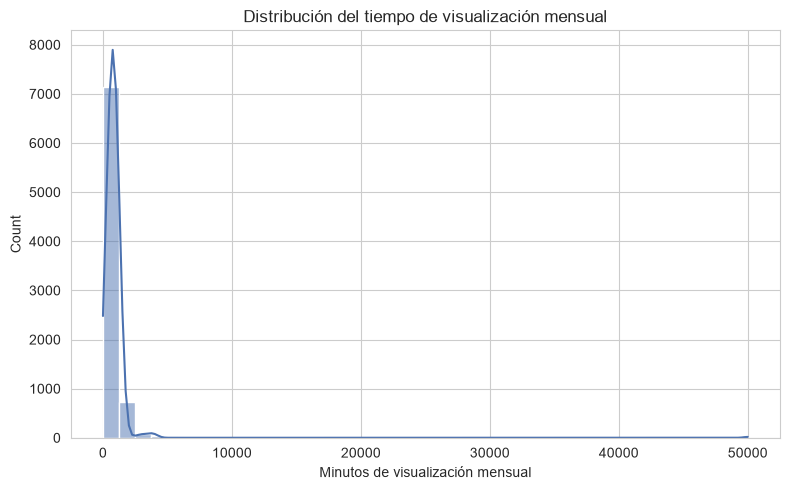

count     8000.000000
mean       868.501900
std       1887.948747
min          0.000000
25%        499.150000
50%        771.350000
75%       1060.300000
max      50000.000000
Name: monthly_watch_time_mins, dtype: float64

In [2]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['monthly_watch_time_mins'], bins=40, kde=True, ax=ax, color='#4C72B0')
ax.set_title('Distribución del tiempo de visualización mensual')
ax.set_xlabel('Minutos de visualización mensual')
plt.tight_layout()
plt.savefig('../reports/fig_univ_watchtime.png', dpi=120)
plt.show()

df['monthly_watch_time_mins'].describe()

**Interpretación:** la distribución del tiempo de visualización es unimodal y con cierta asimetría hacia la derecha (una cola de usuarios con consumo alto). Esto es relevante para nuestra pregunta 1: no hay un "usuario típico" único, sino un rango amplio de consumo, lo cual justifica seguir explorando si ese rango se explica por plan o por país.

C:\Users\ana_9\AppData\Local\Temp\ipykernel_28228\1403074317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='subscription_plan', order=orden_plan, ax=ax, palette='viridis')


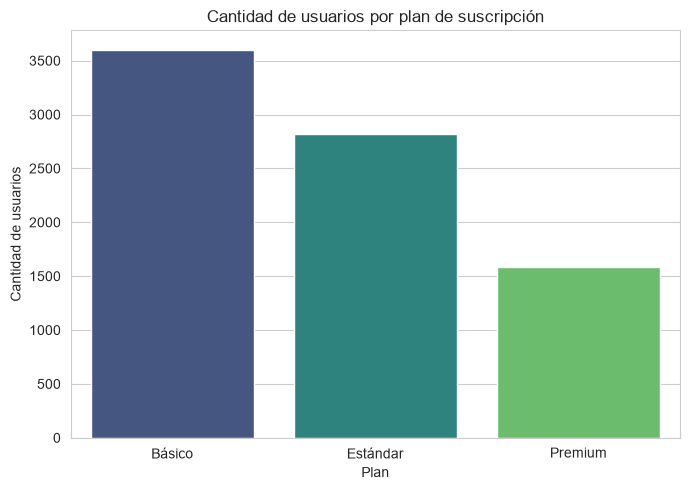

subscription_plan
Básico      3600
Estándar    2817
Premium     1583
Name: count, dtype: int64

In [3]:
fig, ax = plt.subplots(figsize=(7,5))
orden_plan = ['Básico', 'Estándar', 'Premium']
sns.countplot(data=df, x='subscription_plan', order=orden_plan, ax=ax, palette='viridis')
ax.set_title('Cantidad de usuarios por plan de suscripción')
ax.set_xlabel('Plan')
ax.set_ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.savefig('../reports/fig_univ_plan.png', dpi=120)
plt.show()

df['subscription_plan'].value_counts()

**Interpretación:** el plan Básico concentra a la mayoría de los usuarios, seguido de Estándar y luego Premium. Esto importa para leer correctamente los análisis siguientes: si Premium tiene menos usuarios, cualquier patrón que encontremos ahí es sobre un grupo más chico, y hay que tenerlo en cuenta al comparar promedios entre planes.

## 2. Análisis bivariado

C:\Users\ana_9\AppData\Local\Temp\ipykernel_28228\567180654.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', order=orden_plan, ax=ax, palette='viridis')


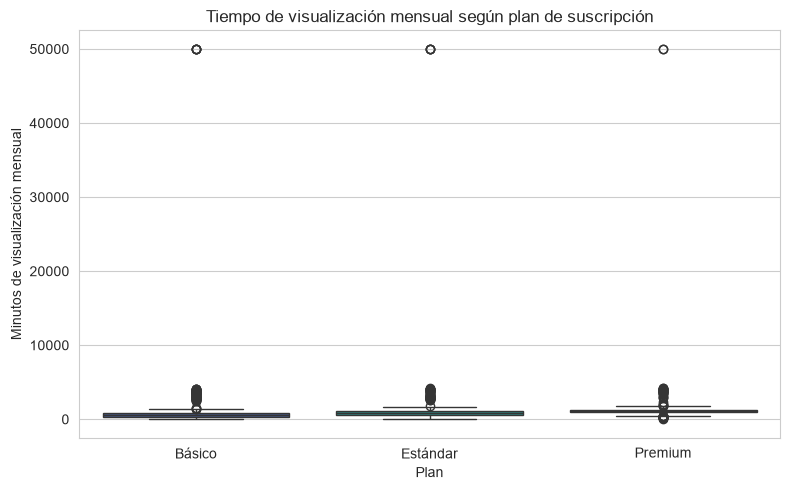

subscription_plan
Básico       552.85
Estándar     839.10
Premium     1121.70
Name: monthly_watch_time_mins, dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', order=orden_plan, ax=ax, palette='viridis')
ax.set_title('Tiempo de visualización mensual según plan de suscripción')
ax.set_xlabel('Plan')
ax.set_ylabel('Minutos de visualización mensual')
plt.tight_layout()
plt.savefig('../reports/fig_biv_plan_watchtime.png', dpi=120)
plt.show()

df.groupby('subscription_plan')['monthly_watch_time_mins'].median().reindex(orden_plan)

**Interpretación (pregunta 2):** acá aparece el hallazgo más claro del proyecto: la mediana de tiempo de visualización **sí varía fuertemente según el plan** -- Básico ronda 553 min/mes, Estándar 839 min/mes y Premium 1122 min/mes. Es prácticamente el doble entre el plan más bajo y el más alto. El plan de suscripción es un fuerte diferenciador del consumo.

C:\Users\ana_9\AppData\Local\Temp\ipykernel_28228\1372206923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y='monthly_watch_time_mins', order=orden_pais, ax=ax, palette='crest')


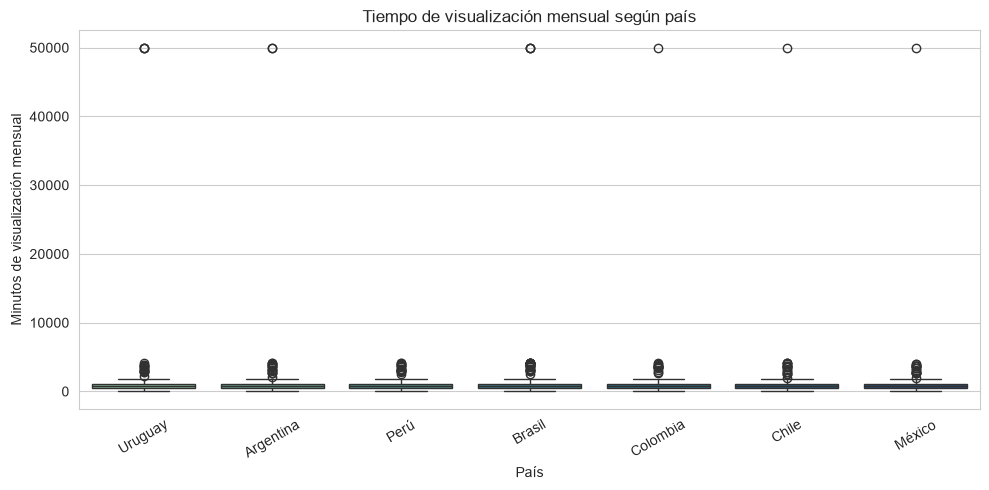

country
Uruguay      795.00
Argentina    783.00
Perú         779.05
Brasil       773.50
Colombia     762.75
Chile        762.65
México       757.70
Name: monthly_watch_time_mins, dtype: float64

In [5]:
orden_pais = df.groupby('country')['monthly_watch_time_mins'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df, x='country', y='monthly_watch_time_mins', order=orden_pais, ax=ax, palette='crest')
ax.set_title('Tiempo de visualización mensual según país')
ax.set_xlabel('País')
ax.set_ylabel('Minutos de visualización mensual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/fig_biv_pais_watchtime.png', dpi=120)
plt.show()

df.groupby('country')['monthly_watch_time_mins'].median().sort_values(ascending=False)

**Interpretación (pregunta 3):** a diferencia del plan, el país muestra diferencias mucho más chicas -- las medianas van de 758 a 795 min/mes, un rango de apenas ~5% entre el país más alto (Uruguay) y el más bajo (México). El país por sí solo aporta poca variabilidad al consumo comparado con el plan.

## 3. Análisis multivariado

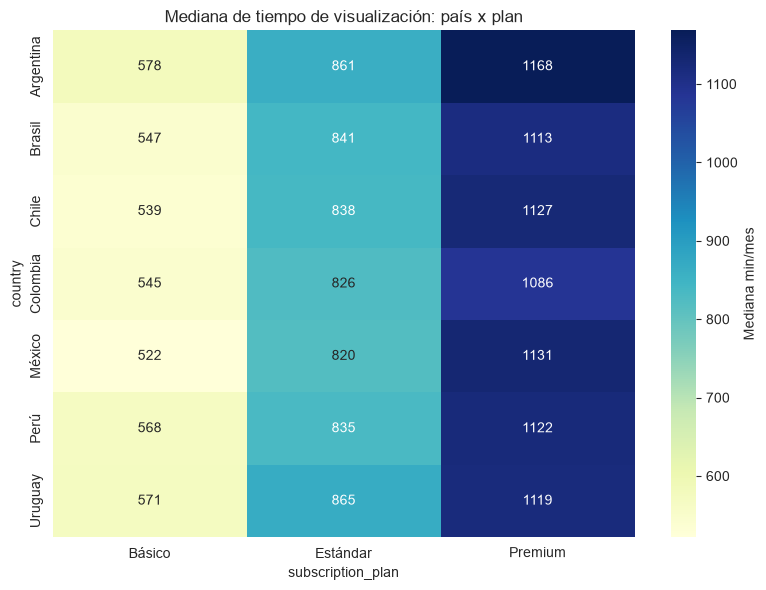

subscription_plan,Básico,Estándar,Premium
country,,,
Argentina,577.9,861.0,1168.3
Brasil,546.6,841.0,1113.2
Chile,539.4,838.5,1126.6
Colombia,544.8,825.8,1085.7
México,521.8,820.0,1130.7
Perú,567.7,834.9,1121.7
Uruguay,571.4,865.3,1118.6


In [6]:
tabla_pivot = df.pivot_table(values='monthly_watch_time_mins', index='country', columns='subscription_plan',
                              aggfunc='median').reindex(columns=orden_plan)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(tabla_pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Mediana min/mes'})
ax.set_title('Mediana de tiempo de visualización: país x plan')
plt.tight_layout()
plt.savefig('../reports/fig_multiv_heatmap.png', dpi=120)
plt.show()

tabla_pivot

**Interpretación (pregunta 4):** el heatmap confirma que el patrón dominante es el del plan: dentro de cada país, subir de Básico a Premium implica un salto de entre 540 y 610 minutos, de forma consistente en los 7 países. El efecto del país es secundario y bastante uniforme -- no aparece una interacción fuerte (un país que se comporte muy distinto a los demás dentro de un mismo plan). En otras palabras: **el plan de suscripción es el principal factor asociado al tiempo de visualización, y el país aporta una variación menor pero consistente** en la misma dirección para todos los planes.

## 4. Síntesis de la etapa

- El tiempo de visualización tiene una distribución con cola hacia la derecha, sin un patrón único de consumo.
- El **plan de suscripción es el factor más asociado al consumo**: la mediana casi se duplica entre Básico y Premium.
- El **país aporta una variación menor** (~5% entre el más alto y el más bajo), consistente en todos los planes.
- No se observa una interacción fuerte entre plan y país: el "salto" al subir de plan es similar en los 7 países, es decir, el efecto del plan no depende demasiado del país.

Este patrón -- una variable categórica (plan) con fuerte asociación al consumo, y otra (país) con aporte menor -- motiva revisar en la siguiente etapa si esta estructura también aparece al reducir dimensionalidad sobre las variables numéricas (`04_pca.ipynb`).